# Medium City Dataset Gallery

Visual check for the original and generated medium-city datasets. The dataset files still use the existing `gas_stations` sheet name for loader compatibility, but this notebook labels them as **refuelling stations** in tables and plots.

In [1]:
import sys
from pathlib import Path

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "src" / "data_loader.py").exists() and (path / "data").exists():
            return path
    raise RuntimeError("Could not find project root containing src/data_loader.py and data/")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data_loader import load_dataset

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")

Project root: /Users/abhimuvva/Documents/Proj_HGQA
Data dir:     /Users/abhimuvva/Documents/Proj_HGQA/data


In [2]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
DATASET_FILES = [
    "dataset_medium_city.xlsx",
    "dataset_medium_city_sparse_suburban.xlsx",
    "dataset_medium_city_polycentric.xlsx",
    "dataset_medium_city_corridor.xlsx",
    "dataset_medium_city_edge_growth.xlsx",
    "dataset_medium_city_underserved_corner.xlsx",
    "dataset_medium_city_dense_core.xlsx",
]

datasets = []
missing = []

for filename in DATASET_FILES:
    path = DATA_DIR / filename
    if not path.exists():
        missing.append(filename)
        continue
    data = load_dataset(str(path))
    data["filename"] = filename
    datasets.append(data)

if missing:
    print("Missing dataset files:", missing)

print(f"Loaded {len(datasets)} medium-city datasets.")

Loaded 7 medium-city datasets.


In [4]:
summary_rows = []

for data in datasets:
    densities = [density for _, _, density in data["pois"]]
    summary_rows.append({
        "dataset": data["dataset_name"],
        "file": data["filename"],
        "POIs": len(data["pois"]),
        "existing chargers": len(data["existing_chargers"]),
        "refuelling stations": len(data["gas_stations"]),
        "m": data["m"],
        "density min": round(min(densities), 2),
        "density mean": round(sum(densities) / len(densities), 3),
        "density max": round(max(densities), 2),
        "description": data["description"],
    })

summary = pd.DataFrame(summary_rows)
summary

,dataset,file,POIs,existing chargers,refuelling stations,m,density min,density mean,density max,description
0,medium_city,dataset_medium_city.xlsx,25,6,5,5,0.30,0.558,0.97,"25 POIs, 6 clusters + corridors, m=5. Tests pr..."
1,medium_city_sparse_suburban,dataset_medium_city_sparse_suburban.xlsx,22,5,6,5,0.26,0.463,0.66,"22 POIs, lower-density suburban pattern with a..."
2,medium_city_polycentric,dataset_medium_city_polycentric.xlsx,27,6,5,5,0.34,0.629,0.96,"27 POIs across downtown, hospital/university, ..."
3,medium_city_corridor,dataset_medium_city_corridor.xlsx,25,6,5,5,0.30,0.608,0.92,25 POIs along a diagonal commuter/highway corr...
4,medium_city_edge_growth,dataset_medium_city_edge_growth.xlsx,26,6,6,5,0.31,0.585,0.94,26 POIs with new growth pushed to north/east e...
5,medium_city_underserved_corner,dataset_medium_city_underserved_corner.xlsx,24,6,6,5,0.31,0.561,0.93,24 POIs with high demand in the southwest corn...
6,medium_city_dense_core,dataset_medium_city_dense_core.xlsx,30,6,5,5,0.25,0.597,0.98,"30 POIs with heavy downtown pressure, secondar..."


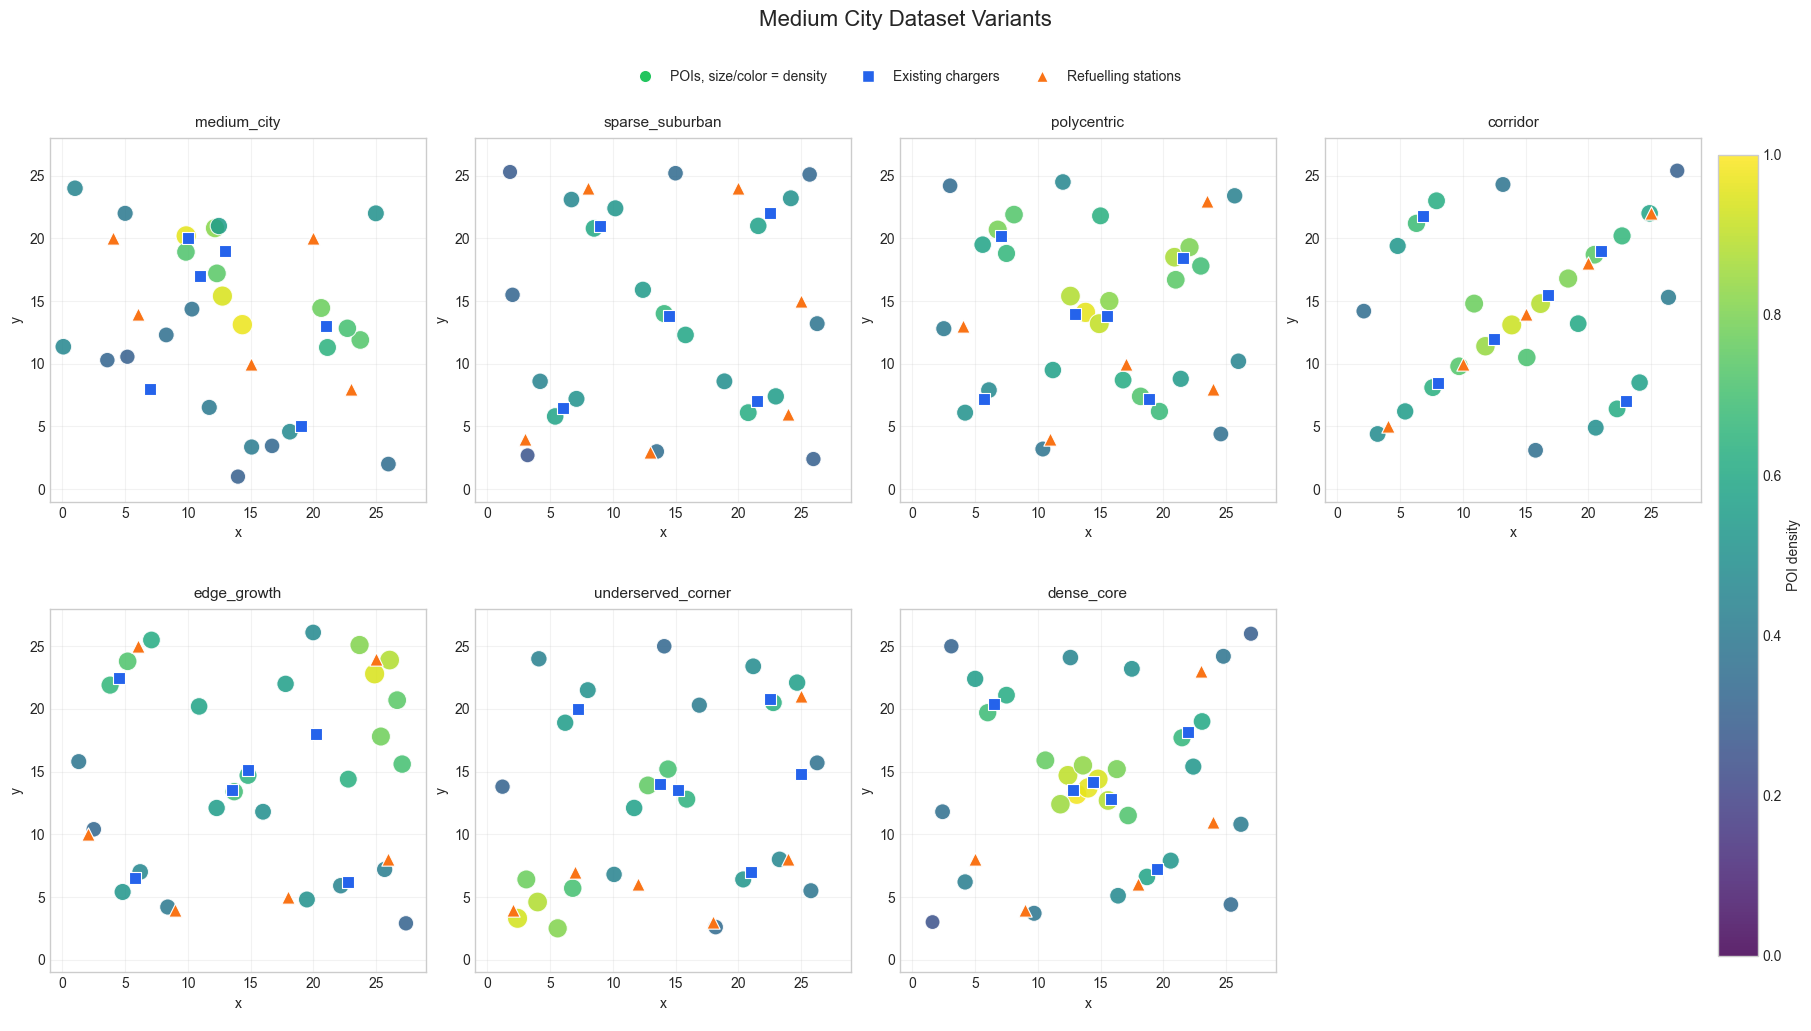

In [5]:
def plot_dataset(ax, data):
    pois = data["pois"]
    chargers = data["existing_chargers"]
    refuelling = data["gas_stations"]

    x = [point[0] for point in pois]
    y = [point[1] for point in pois]
    density = [point[2] for point in pois]

    scatter = ax.scatter(
        x, y,
        c=density,
        cmap="viridis",
        vmin=0,
        vmax=1,
        s=[80 + 140 * d for d in density],
        alpha=0.86,
        edgecolor="white",
        linewidth=0.8,
        label="POIs",
    )

    if chargers:
        cx, cy = zip(*chargers)
        ax.scatter(cx, cy, marker="s", s=80, color="#2563eb", edgecolor="white", linewidth=0.8, label="Existing chargers")

    if refuelling:
        rx, ry = zip(*refuelling)
        ax.scatter(rx, ry, marker="^", s=92, color="#f97316", edgecolor="white", linewidth=0.8, label="Refuelling stations")

    ax.set_title(data["dataset_name"].replace("medium_city_", ""), fontsize=11, pad=8)
    ax.set_xlim(data["x_min"] - 1, data["x_max"] + 1)
    ax.set_ylim(data["y_min"] - 1, data["y_max"] + 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.25)
    return scatter

cols = 4
rows = math.ceil(len(datasets) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 4.7 * rows), constrained_layout=True)
axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

last_scatter = None
for ax, data in zip(axes, datasets):
    last_scatter = plot_dataset(ax, data)

for ax in axes[len(datasets):]:
    ax.axis("off")

legend_handles = [
    mlines.Line2D([], [], color="none", marker="o", markerfacecolor="#22c55e", markeredgecolor="white", markersize=9, label="POIs, size/color = density"),
    mlines.Line2D([], [], color="none", marker="s", markerfacecolor="#2563eb", markeredgecolor="white", markersize=9, label="Existing chargers"),
    mlines.Line2D([], [], color="none", marker="^", markerfacecolor="#f97316", markeredgecolor="white", markersize=9, label="Refuelling stations"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.03))

if last_scatter is not None:
    cbar = fig.colorbar(last_scatter, ax=axes[:len(datasets)], shrink=0.86, pad=0.01)
    cbar.set_label("POI density")

fig.suptitle("Medium City Dataset Variants", fontsize=16, y=1.08)
plt.show()

In [6]:
for data in datasets:
    print(f"{data['dataset_name']}  |  {data['filename']}")
    print(f"  {data['description']}")
    print(f"  POIs={len(data['pois'])}, existing chargers={len(data['existing_chargers'])}, refuelling stations={len(data['gas_stations'])}, m={data['m']}")
    print()

medium_city  |  dataset_medium_city.xlsx
  25 POIs, 6 clusters + corridors, m=5. Tests pruning at 144-400 cells.
  POIs=25, existing chargers=6, refuelling stations=5, m=5

medium_city_sparse_suburban  |  dataset_medium_city_sparse_suburban.xlsx
  22 POIs, lower-density suburban pattern with a few neighborhood centers and many separated POIs; tests sparse coverage, m=5.
  POIs=22, existing chargers=5, refuelling stations=6, m=5

medium_city_polycentric  |  dataset_medium_city_polycentric.xlsx
  27 POIs across downtown, hospital/university, retail, and residential districts; mixed dense and moderate clusters, m=5.
  POIs=27, existing chargers=6, refuelling stations=5, m=5

medium_city_corridor  |  dataset_medium_city_corridor.xlsx
  25 POIs along a diagonal commuter/highway corridor plus two off-corridor neighborhoods; tests linear spatial bias, m=5.
  POIs=25, existing chargers=6, refuelling stations=5, m=5

medium_city_edge_growth  |  dataset_medium_city_edge_growth.xlsx
  26 POIs wit